### Bước 1: Nhập và tiền xử lý ảnh

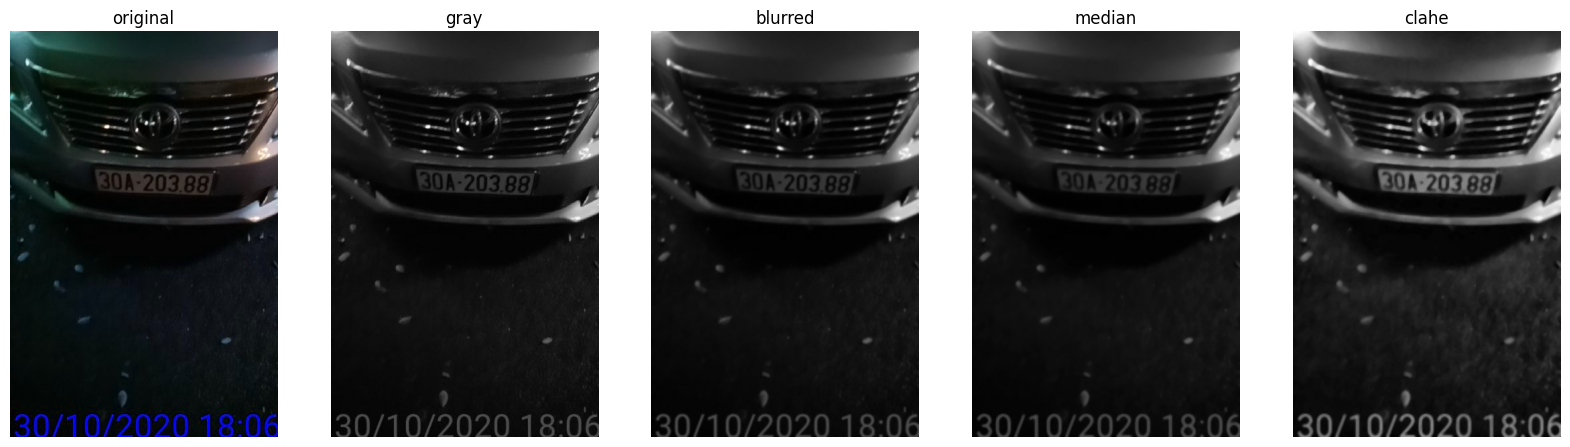

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Hàm để hiển thị hình ảnh
def display_image(images, titles):
    plt.figure(figsize=(20,10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
def load_and_preprocess(image_path):
    # 1. Tải ảnh
    original_image = cv2.imread(image_path)
    if original_image is None:
        print("Lỗi: Không thể tải ảnh.")
    else:
        # 2. Tiền xử lý 
        # Chuyển đổi sang ảnh xám
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        # Gaussian Blur để giảm nhiễu
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Median Filter để giảm nhiễu nhiều hơn
        median_image = cv2.medianBlur(blurred_image, 5)
        # CLAHE để tăng cường độ tương phản
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(median_image)
        # 3. Trả về một dictionary để dễ dàng truy cập các bước
        return {
            "original": original_image,
            "gray": gray_image,
            "blurred": blurred_image,
            "median": median_image,
            "clahe": clahe_image
        }
# Test 
image_path = 'data/test_images/CarTGMT/AQUA4_20388_checkin_2020-10-30-18-6Lp7OpJkuYv.jpg'
process_images = load_and_preprocess(image_path)
if process_images:
    display_image(list(process_images.values()), list(process_images.keys()))